Տնային առաջադրանքը կատարելու վերջնաժամկետը **07.06.2021 15:30** է։ Առաջադրանքները կատարելուց հետո, պետք է 
 
1. ներբեռնեք այս ֆայլը ձեր համակարգիչ (`File` $\to$ `Download .ipynb`)
 
2. ներբեռնեք լրացված ``.py`` ֆայլերը
 
3. վերոնշյալ ֆայլերը ``.zip`` արեք և վերնագրեք հետևյալ ֆորմատով՝ 
    *HW3_AnunAzganunyan.zip* 
 
4. ուղարկեք ֆայլը **fast.1991.ml@gmail.com** հասցեին` նամակի թեմա (subject) դաշտում գրելով **ML3**
 
5. տնայինը կրկին անգամ ուղարկելու դեպքում պատասխանել (reply/ответить) նախորդ նամակին 
 
**Ուշադրություն**․ 
Վերոնշյալ պայմաններին չբավարարելու դեպքում ձեր աշխատանքը չի գնահատվի։

# Support Vector Machine

Complete the code in `Courses 3rd batch/MachineLearning/Labs/Lab_files/Lab3/svm.py`. For that first you need to get familiar with one of the following packages for solving convex optimization problems in Python:

* [`cvxopt`](https://courses.csail.mit.edu/6.867/wiki/images/a/a7/Qp-cvxopt.pdf) 

* [`cvxpy`](https://www.cvxpy.org/examples/basic/quadratic_program.html)

Note that the comments and hints in the `svm.py` are written for `cvxopt` but you are encouraged to try `cvxpy`, which is more user-friendly. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid') # Plot style

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

%load_ext autoreload
%autoreload 2

from svm import SVM

ModuleNotFoundError: No module named 'cvxopt'

First let's check it on the toy dataset.

In [2]:
x1 = np.array([5, 6, 7, 7, 8, 9, 0, 1, 2, 4, 5, 6])
x2 = np.array([2, 1, 3, 5, 10, 3, 4, 8, 6, 10, 9, 11])
y = np.array([1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1])

data = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})
data.head()

,x1,x2,y
0,5,2,1
1,6,1,1
2,7,3,1
3,7,5,1
4,8,10,1


In [3]:
X = data.iloc[:,:-1].values
y = data.iloc[:, -1].values.copy()

model = SVM(C=0)
model.fit(X, y)

In [4]:
def plot_data(data): 
  plt.figure(figsize=(8, 6))
  plt.plot(data.loc[data.y==1, 'x1'], data.loc[data.y==1, 'x2'],
          'ro' , label='positives') 
  plt.plot(data.loc[data.y==-1, 'x1'], data.loc[data.y==-1, 'x2'],
          'bo' , label='negative') 

  min_x1 = np.min(data['x1'])
  max_x1 = np.max(data['x1'])
  min_x2 = np.min(data['x2'])
  max_x2 = np.max(data['x2'])

  plt.legend(markerscale=1, loc='upper left', 
            frameon=True, shadow=True, fontsize=12)

  plt.xticks(list(range(min_x1-1, max_x1+2)))
  plt.yticks(list(range(min_x2-1, max_x2+2)))
  plt.xlim(min_x1-1, max_x1+1)
  plt.ylim(min_x2-1, max_x2+1)
  
  plt.xlabel('$x_1$', size=12)   
  plt.ylabel('$x_2$', size=12)

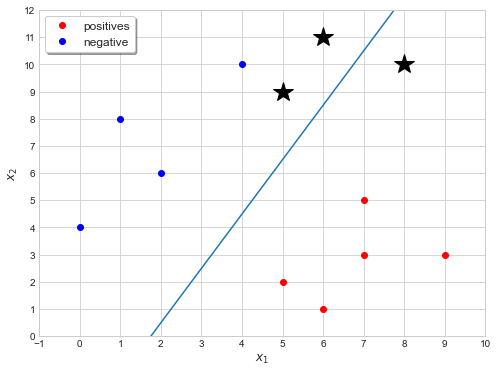

In [6]:
plot_data(data)
w = model.w
t = model.t 
x = np.arange(-5,15)
plt.plot(x, -w[0] / w[1] * x + t / w[1])
for i in model.support_vectors:
  # marking the support vectors with star markers
  plt.plot(*i, marker='*', markersize=20, color='k')
plt.show()

Now let's check the performance of the algorithm on the synthetic dataset without one of the labels.

In [5]:
def synthetic_dataset():
    '''Generate 3 Gaussian samples with different covariance matrices'''
    n, dim = 300, 2
    np.random.seed(0)
    cov1 = np.array([[1, -1],
                     [-1, 2]])
     
    cov2 = np.array([[0.5, 0.2],
                     [0.2, 0.5]])
    
    cov3 = np.array([[2, -0.5],
                     [-0.5, 0.2]])

    # inputs
    X = np.vstack((np.random.multivariate_normal(mean=[0, 0], cov=cov1, size=n),
                   np.random.multivariate_normal(mean=[2, 2], cov=cov2, size=n),
                   np.random.multivariate_normal(mean=[-3, 3], cov=cov3, size=n)
                   ))
    # labels 0, 1, 2
    y = np.hstack((np.zeros(n), np.ones(n), np.ones(n) * 2))

    return X, y

Xs, ys = synthetic_dataset()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(Xs[ys!=0], ys[ys!=0],
                                                    test_size=0.25,
                                                    random_state=0)
y_train[y_train == 2] = -1
y_test[y_test == 2] = -1

Hard-margin SVM (C=None) performs very badly on this dataset, it results in $46\%$ accuracy

In [7]:
model = SVM(C=None)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy_score(predictions, y_test)

0.4666666666666667

But when we use regularization, things get much better.

In [10]:
model = SVM(C=0.01)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy_score(predictions, y_test)

0.9933333333333333

We even reach to perfect classification when setting $C=1$. Think about the reasons why we get this kind of differences (visualizing may help).

In [8]:
model = SVM(C=1)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy_score(predictions, y_test)

1.0

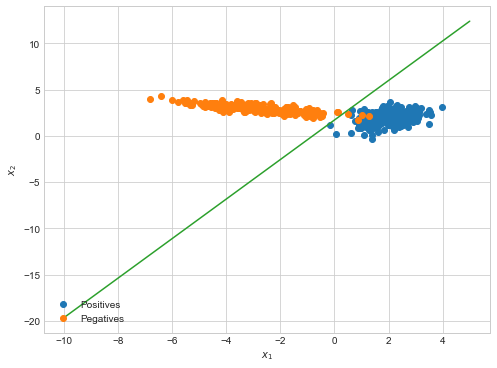

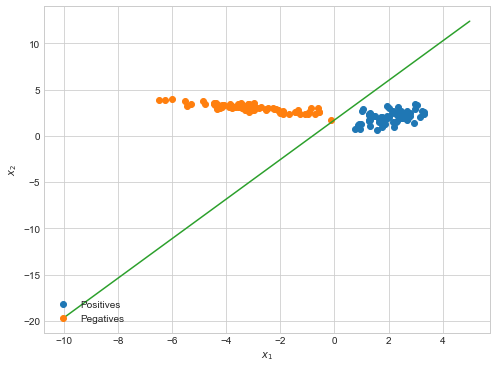

In [9]:
#running this cell with model = SVM(C=0.01) we can see that on the test data(on the 2nd plot) we have only one wrong prediction 
#with model = SVM(C = 1) on the test data we don't have any wrong predictions and on C = 0 we get comletely wrong w and t.
def visulaization(X, y, w, t):

    X_train= pd.DataFrame(X)
    y_train = np.array(y)

    plt.figure(figsize=(8, 6))
    plt.plot(X_train[y_train == 1].iloc[:, 0], X_train[y_train == 1].iloc[:, 1], 'o', label = 'Positives')
    plt.plot(X_train[y_train == -1].iloc[:, 0], X_train[y_train == -1].iloc[:, 1], 'o', label = 'Pegatives')

    plt.xlabel("$x_1$")
    plt.ylabel('$x_2$')

    plt.legend(loc = 'lower left')
    
    x = np.linspace(-10,5,100)
    plt.plot(x, -w[0] / w[1] * x + t / w[1])
    
    plt.show()
    

    
visulaization(X_train, y_train, model.w, model.t)
visulaization(X_test, y_test, model.w, model.t)


Let's also check with `sklearn`'s implementation.

In [10]:
from sklearn.svm import SVC

model = SVC(C=1e-18, kernel='linear')
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy_score(predictions, y_test)

0.4666666666666667

In [11]:
model = SVC(C=0.01, kernel='linear')
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy_score(predictions, y_test)

0.9933333333333333

In [12]:
model = SVC(C=1, kernel='linear')
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy_score(predictions, y_test)

1.0

# SVM with Kernels

Complete the code in `Courses 3rd batch/MachineLearning/Labs/Lab_files/Lab3/svm_with_kernels.py`.

You're already familiar with famous Titanic dataset from [kaggle](https://www.kaggle.com/c/titanic). A copy of it can be found in `Courses 3rd batch/MachineLearning/Labs/Lab_files/Lab3/train.csv`.

In [13]:
df = pd.read_csv('train.csv')
data_with_age = df[['Pclass', 'Sex', 'Age', 'Survived']]
data_with_age = data_with_age.dropna()
data = pd.get_dummies(data_with_age, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(data.drop(columns='Survived'),
                                                      data.Survived,
                                                      random_state=0)

In [15]:
y_train[y_train==0] = -1  # our implementation requires 1, -1 encoding of labels
y_test[y_test==0] = -1

In [3]:
from svm_with_kernels import SupportVectorMachine
model = SupportVectorMachine(kernel_name='poly')

ModuleNotFoundError: No module named 'cvxopt'

In [17]:
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy_score(prediction, y_test) 

0.7653631284916201

Here you should get about $76\%$ accuracy.

In [18]:
model = SupportVectorMachine(kernel_name='rbf', gamma=0.9)
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy_score(prediction, y_test)

0.770949720670391

Here you should get about $77\%$ accuracy.


Experiment with your implementation to train a good model on this training dataset. Try different values for the hyperparameters.